[6.67       1.57333333]


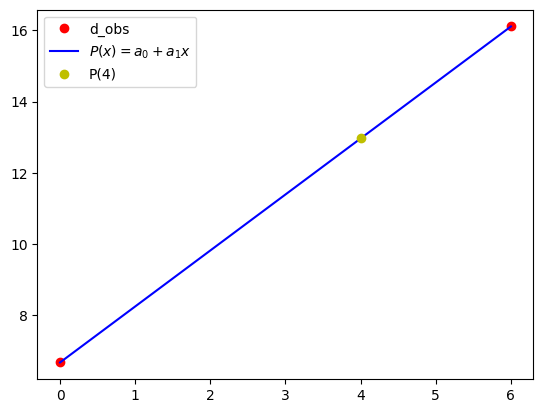

In [1]:
import sel as sel
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[1,0],[1,6]], float)
b = np.array([6.67, 16.11], float)
x_data = [0,6]
y_data = b = np.array([6.67, 16.11], float)
a_i = sel.eliminacion_gaussiana(A,b)
print(a_i)

P = lambda x: a_i[0] + a_i[1] * x

ux = np.linspace(min(x_data), max(x_data), 10)
plt.plot(x_data, y_data, 'or', label = 'd_obs')
plt.plot(ux, P(ux), 'b', label = '$P(x) = a_0 + a_1x$')
plt.plot(4, P(4), 'oy', label = 'P(4)')
plt.legend()
plt.show()

# Ejemplo 2:

Construir un polinomio de maximo grado  para el conjunto de datos:

|Dia  | 0   |6   | 10   |
|-----|-----|----|----  |
|peso |6.67 |16.11|18.89|	

donde se estudia el crecimiento de larvas criadas en hojas maduras de un roble. Aproxime el perso en el 4 dia de crecimiento

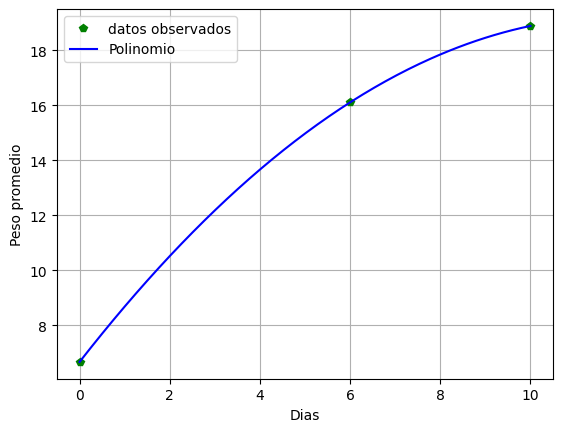

In [2]:

def Matrix(x_data):
    n = len(x_data)
    A = np.zeros([n,n], float)
    A[0:n, 0] = 1

    for j in range (1,n):
        for i in range(n):
            A[i,j]=A[i,j-1]*x_data[i]
    return A

dia = np.array([0,6,10])
peso = np.array([6.67, 16.11, 18.89])
A = Matrix(dia)
coeficientes = sel.eliminacion_gaussiana(A, peso)
Polinomio = lambda x: sum(coeficientes[i]*x**i for i in range(len(dia)))
x_values = np.linspace(min(dia), max(dia), 200)
plt.plot(dia, peso, "pg", label = 'datos observados')
plt.plot(x_values, Polinomio(x_values), 'b', label = 'Polinomio')
plt.legend()
plt.xlabel("Dias")
plt.ylabel("Peso promedio")
plt.grid()
plt.show()

\# Ejercicio

Se sospecha que las grandes cantidades de tanino en las hojas maduras de los robles inhiben el crecimiento de la larva de 

polilla de invierno (Operophtera bromata L., Geometridae) que daña en exceso estos árboles en ciertos años. La siguiente tabla enumera el peso promedio de dos muestras de la larva en los primeros 28 días después de su nacimiento. Mientras la primera muestra se crió en las hojas jóvenes de roble, la segunda muestra se crió en las hojas maduras.



|	Día	|  	0	|	 6 	|	10	 |	13	|	17	|	20	|	28	|
|---------------|---------------|---------------|----------------|--------------|---------------|---------------|---------------|
|muestra 1 (mg) |	6.67	|	17.33	|	42.67    |	 37.33	|	30.10	|	29.31	|    28.74 	|
|muestra 2(mg)  |	6.67	|	16.11	|	18.89	 |	15.00	|	10.56	|9.44		|	8.89	|



1\. Construir un polinomio para obtener la curva de peso promedio para cada muestra

2\. Encuentre un peso promedio máximo aproximado para cada muestra( determinando el máximo del polinomio, usando un método de ceros de funciones)

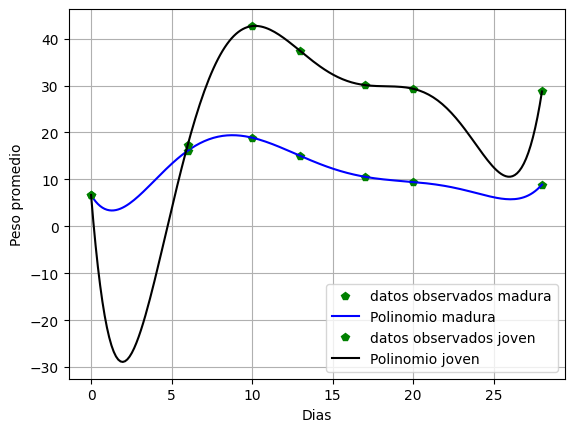

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sel as sel
import modelos as m
import ceros as zero
dia = np.array([0,6,10,13,17,20,28])

A = m.Matrix(dia)

# Crecimiento de larvas en hojas maduras

peso_larva_madura = np.array([6.67, 16.11, 18.89, 15.00, 10.56, 9.44, 8.89])

#Coeficientes larvas maduras


coef_madura = sel.eliminacion_gaussiana(A, peso_larva_madura)
P_madura = lambda x: sum(coef_madura[i] *x ** i for i in range (len(dia)))


# Crecimiento de larvas en hojas jovenes

peso_larva_joven = np.array([6.67, 17.33,42.67, 37.33, 30.10, 29.31, 28.74])

#Coeficientes larvas jovenes

coef_joven = sel.eliminacion_gaussiana(A, peso_larva_joven)
P_joven = lambda x: sum(coef_joven[i] *x ** i for i in range (len(dia)))


x_values = np.linspace(min(dia), max(dia), 200)
plt.plot(dia, peso_larva_madura, "pg", label = 'datos observados madura')
plt.plot(x_values, P_madura(x_values), 'b', label = 'Polinomio madura')
plt.plot(dia, peso_larva_joven, "pg", label = 'datos observados joven')
plt.plot(x_values, P_joven(x_values), 'k', label = 'Polinomio joven')

plt.legend()
plt.xlabel("Dias")
plt.ylabel("Peso promedio")
plt.grid()
plt.show()




In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sel as sel
import modelos as m
import ceros as zero



In [5]:
import sympy as sp 
import ceros as zero

x = sp.symbols('x')
P_joven = sum(coef_joven[i]*x**i for i in range (len(dia)))
dia_max = zero.newton_rapshon2(sp.diff(P_joven,x), 10, 1e-6)

print(f"El dia que la muestra alcanza su peso promedio maximo es: {dia_max} y su peso es {P_joven.evalf(subs={x:dia_max})}mg")

El dia que la muestra alcanza su peso promedio maximo es: 10.1885297651615 y su peso es 42.7084211919494mg


Ejercicio clase 22/04/26

In [ ]:
import numpy as np
import sel as sel
import modelos as ml 
import matplotlib.pyplot as plt
import sympy as sp
x = sp.symbols('x')

dia = np.array([0,6,10])
peso = np.array([6.67, 16.11, 18.89])
Poly = ml.Polinomial_simple(dia, peso)
print(Poly)

P = (((x-0.6)(x-0.6) / 0.54)(1)) + (x(x-0.9) / (-0.18)) * (1.264911) + ((x(x-0.6) / (0.27)) * )

-0.0878333333333333*x**2 + 2.10033333333333*x + 6.67


In [ ]:
#polinomio de lagrange

x_data = np.array([])
y_data = np.array([])



P = Lagrange(x_data, y_data)
print(P)


Ejercicio 1

La tabla muestra cómo varía la densidad relativa $\rho$ del aire con la altitud  $h$.  


|h(km)	| 0	|1.525	|3.050	|4.575	|6.10	|7.625	|9.150	|
|----------|-------|---------|-----------|----------|-------|---------|--------|
|ρ	|1	|0.8617  |0.7385	|0.6292	|0.5238     |0.4481	|0.3741   |


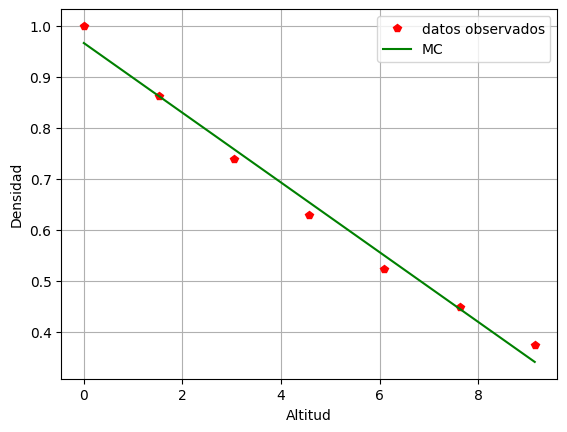

In [5]:
#funcion minimos cuadrados
import numpy as np
import matplotlib.pyplot as plt
x_values = np.array([0,1.525,3.050,4.575,6.10,7.625,9.150])
y_values = np.array([1,0.8617, 0.7385, 0.6292, 0.5238, 0.4481, 0.3741])

def minimos_cuadrados(x_values, y_values):
    n = len(x_values)

    sum_x = sum(x_values)

    sum_y = sum(y_values)

    sum_yx = sum(x_values * y_values)

    sum_x2 = sum(x_values**2)

    sum_y2 = sum(y_values**2)

    m = (n*sum_yx-sum_x*sum_y) / (n*sum_x2-sum_x**2)

    b =  (sum_x2 * sum_y - sum_x * sum_yx) / (n*sum_x2-sum_x**2)

    return m, b

m,b = minimos_cuadrados(x_values, y_values)

P = lambda x: m*x+b
x_valores = np.linspace(min(x_values), max(x_values), 200)
plt.plot(x_values, y_values, 'pr', label='datos observados')
plt.plot(x_values, P(x_values), 'g', label = 'MC')
plt.legend()
plt.xlabel('Altitud')
plt.ylabel('Densidad')
plt.grid()
plt.show()

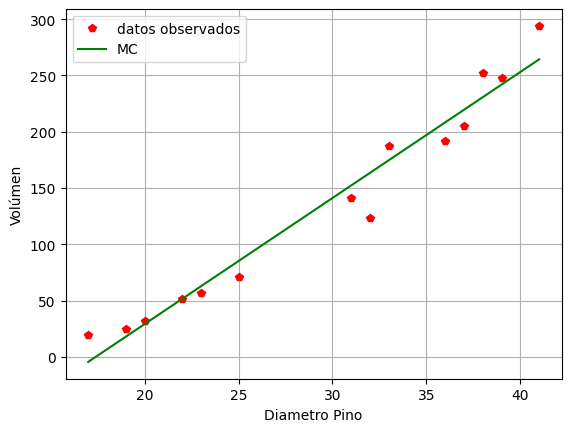

In [ ]:
from modelos import Polinomial_simple
from modelos import minimos_cuadrados
import numpy as np  
import matplotlib.pyplot as plt


x_data = np.array([17,19,20,22,23,25,31,32,33,36,37,38,39,41])
y_data = np.array([19,25,32,51,57,71,141,123,187,192,205,252,248,294])

pendiente, b = minimos_cuadrados(x_data, y_data)

P1 = lambda x: pendiente*x+b

# P2 = lambda x: Polinomial_simple(x_data, y_data)


x_values = np.linspace(min(x_data), max(x_data), 200)

plt.plot(x_data, y_data, 'pr', label='datos observados')
plt.plot(x_values, P1(x_values), 'g', label = 'MC')

plt.legend()
plt.xlabel('Diametro Pino')
plt.ylabel('Volúmen')
plt.grid()
plt.show()






-592.1006774902344


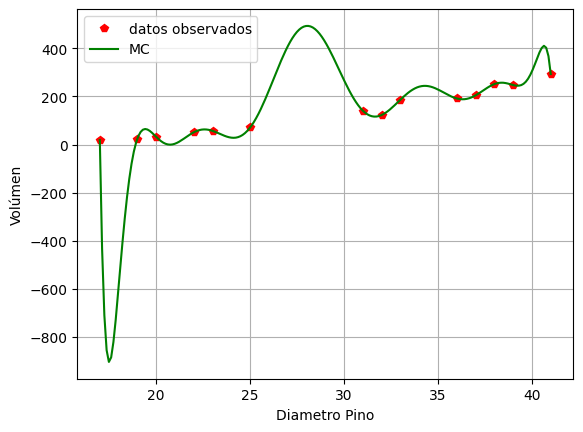

In [26]:
from modelos import Polinomial_simple
import numpy as np  
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x')

x_data = np.array([17,19,20,22,23,25,31,32,33,36,37,38,39,41])
y_data = np.array([19,25,32,51,57,71,141,123,187,192,205,252,248,294])

P2 = Polinomial_simple(x_data, y_data)
P2 = sp.lambdify(x, P2)

x_values = np.linspace(min(x_data), max(x_data), 200)
plt.plot(x_data, y_data, 'pr', label='datos observados')
plt.plot(x_values, P2(x_values), 'g', label = 'MC')
print(P2(18))

plt.legend()
plt.xlabel('Diametro Pino')
plt.ylabel('Volúmen')
plt.grid()
plt.show()

In [ ]:
#Evaluacion
P1(18)
P1(28)

<class 'function'>


In [ ]:
#Evaluacion
P2(18)
P2(28)